# LangGraph 기초

In [2]:
from dotenv import load_dotenv

load_dotenv()

True

## Chain의 한계

LCEL Chain은 **직선 파이프라인**이다.

```
입력 → A → B → C → 출력
```

이 구조에서 **불가능한 것**들이 있다.

| 한계 | 설명 | 예시 |
|------|------|------|
| **조건 분기** | 중간에 경로를 나눌 수 없음 | 환불 요청이면 A, 일반 문의면 B |
| **반복** | 이전 단계로 돌아갈 수 없음 | 검색 결과 부족 시 질문 바꿔서 재검색 |
| **상태 관리** | 여러 단계에 걸친 중간 결과 누적 불가 | 리서치 → 누적 → 추가 리서치 → 종합 |
| **사람의 개입** | 중간에 멈추고 확인 받을 수 없음 | 결제 전 사람의 승인 대기 |

### 억지로 구현하면

"검색 결과가 부족하면 질문을 바꿔서 다시 검색"하는 로직을 Chain으로 시도해보자.

In [3]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

vectorstore = Chroma(
    embedding_function=embeddings,
    collection_name="spri_ai_brief",
    persist_directory="./chroma_db",
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [20]:
from langchain_core.messages import HumanMessage, AIMessage

question = "AI 반도체 시장의 전망은?"
max_retries = 3

for attempt in range(max_retries):
    docs = retriever.invoke(question)
    context = format_docs(docs)

    check = llm.invoke([
        HumanMessage(
            content=f"질문: {question}\n\n검색 결과:\n{context}\n\n"
            "이 검색 결과가 질문에 답변하기에 충분한가? 'yes' 또는 'no'로만 답해."
        )
    ])

    print(f"[시도 {attempt + 1}] 질문: {question}")
    print(f"  충분한가? {check.content}")

    if "yes" in check.content.lower():
        break

    rewrite = llm.invoke([
        HumanMessage(
            content=f"'{question}'이라는 질문으로 문서를 검색했지만 충분한 결과가 없었다. "
            "같은 의도이지만 다른 표현으로 질문을 다시 작성해줘. 질문만 출력해."
        )
    ])
    question = rewrite.content

print(f"\n→ Chain 밖에서 Python 루프로 제어하고 있다.")
print("→ Chain의 장점(재사용, 스트리밍, 트레이싱)을 잃는다.")

NameError: name 'retriever' is not defined

## Workflow vs Agent

AI 애플리케이션의 제어 방식은 **스펙트럼** 위에 있다.

```
개발자가 흐름 결정                                    LLM이 흐름 결정
├──────────────────────────────────────────────────────────┤
Chain       Workflow        Agent           Autonomous Agent
(직선)       (분기+루프)     (LLM이 판단)            (완전 자율)
```

| 방식 | 제어 주체 | 예시 |
|------|----------|------|
| **Chain** | 개발자가 모든 흐름을 고정 | 번역 → 요약 → 출력 |
| **Workflow** | 개발자가 분기/루프 설계 | 검색 결과 부족하면 재검색 |
| **Agent** | LLM이 다음 행동을 결정 | 어떤 Tool을 몇 번 쓸지 LLM이 판단 |

Chain은 스펙트럼의 가장 왼쪽이다. **LangGraph는 이 스펙트럼 전체를 구현할 수 있는 프레임워크**다.

## LangGraph 핵심 개념

LangGraph는 3가지 개념으로 구성된다.

| 개념 | 역할 | 비유 |
|------|------|------|
| **State** | 전체 흐름에서 공유하는 데이터 | 칠판 — 모든 노드가 읽고 쓸 수 있음 |
| **Node** | 각 처리 단계 (Python 함수) | 작업자 — State를 받아서 처리하고 결과를 돌려줌 |
| **Edge** | 노드 간의 연결 | 화살표 — 다음에 어떤 노드로 갈지 결정 |


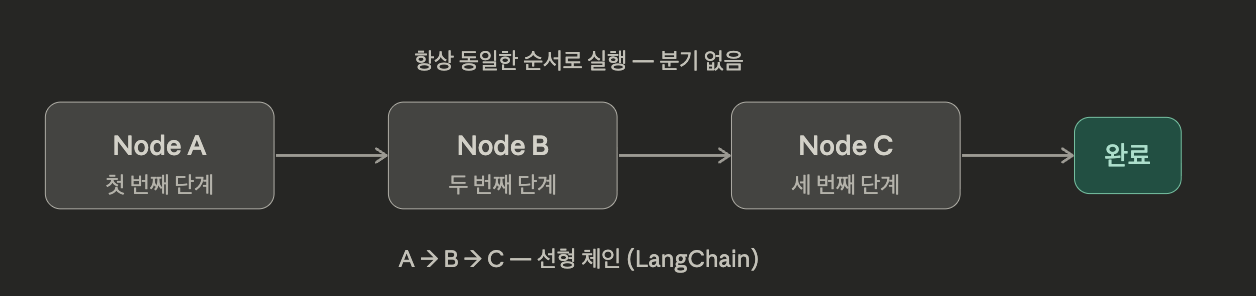

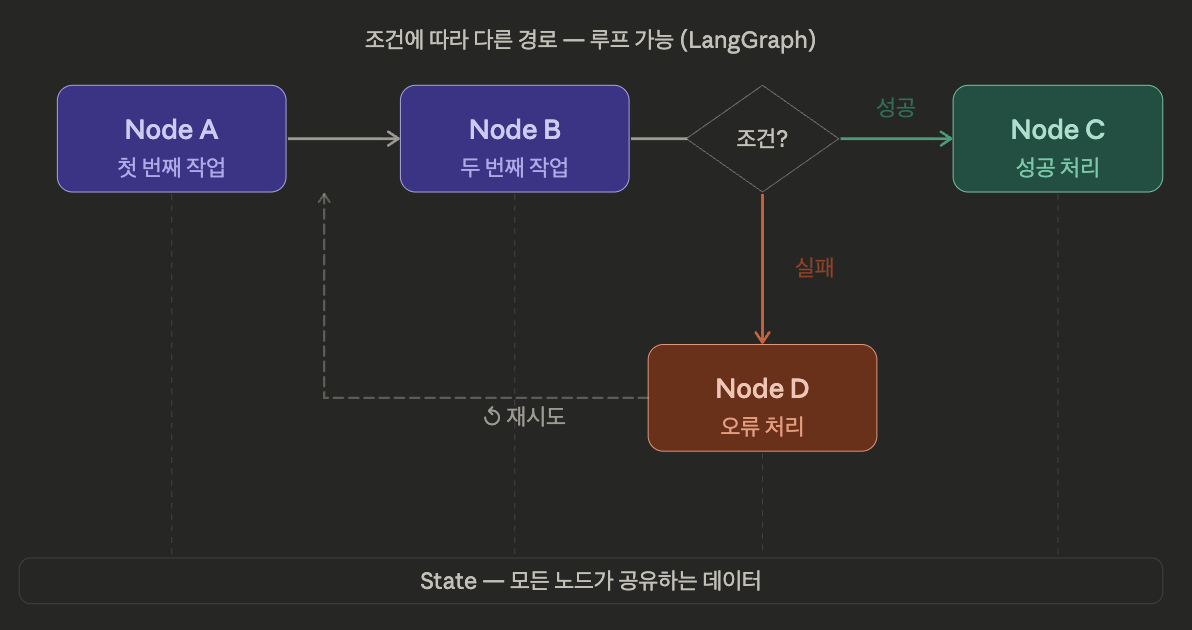

## 설치

In [ ]:
# uv add langgraph

## 기본 그래프

LLM 하나를 노드로 사용하는 가장 기본적인 그래프를 만들어보자.

```
START → chatbot → END
```

### State 정의

State는 그래프 전체에서 공유하는 데이터 구조다. `TypedDict`로 정의한다.

`TypedDict`는 Python 표준 라이브러리(`typing`)에 포함된 타입으로, **딕셔너리의 키와 값 타입을 명시**할 수 있다.

```python
# 일반 dict — 어떤 키가 있는지, 값이 무슨 타입인지 알 수 없음
state = {"name": "홍길동", "age": 30}

# TypedDict — 키 이름과 타입이 명확
class State(TypedDict):
    name: str
    age: int
```

런타임에는 일반 `dict`와 동일하게 동작하지만, IDE 자동완성과 타입 검사를 지원한다.

In [2]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]

`Annotated[list, add_messages]`는 **reducer** 패턴이다.

**Reducer**란 "이전 값과 새 값을 받아서 합치는 함수"다. 값을 덮어쓰는 대신, **어떻게 합칠지**를 정의한다.

```
reducer(기존 값, 새 값) → 합쳐진 값
```

`Annotated`의 두 번째 인자가 이 reducer 함수 역할을 한다.

- `list` = 타입
- `add_messages` = reducer 함수 — 이 필드가 업데이트될 때 **덮어쓰기가 아니라 추가**

```python
# reducer 없음 (기본 동작: 덮어쓰기)
messages: list  # {"messages": [새 메시지]} → 기존 메시지 사라짐

# reducer 있음 (add_messages)
messages: Annotated[list, add_messages]  # {"messages": [새 메시지]} → 기존 + 새 메시지
```

### Node 정의

노드는 **Python 함수**다. State를 받아서 업데이트할 내용을 반환한다.

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


노드 함수의 패턴은 항상 동일하다.

1. `state`를 인자로 받는다
2. state에서 필요한 데이터를 꺼내 처리한다
3. 업데이트할 필드를 dict로 반환한다

반환된 dict는 State에 **병합**된다. `messages`에 `add_messages` reducer가 있으므로 기존 메시지에 새 메시지가 추가된다.

### Graph 구성 + Edge 연결

In [4]:
# 그래프 생성
graph_builder = StateGraph(State)

# 노드 추가 (이름, 함수)
graph_builder.add_node("chatbot", chatbot)

# 엣지 추가
graph_builder.add_edge(START, "chatbot")  # 시작 → chatbot
graph_builder.add_edge("chatbot", END)    # chatbot → 종료

# 컴파일
graph = graph_builder.compile()

순서를 정리하면:

1. `StateGraph(State)` — State 스키마로 그래프 생성
2. `add_node(이름, 함수)` — 노드 등록
3. `add_edge(출발, 도착)` — 노드 간 연결
4. `compile()` — 실행 가능한 그래프로 변환

### 시각화

LangGraph는 그래프 구조를 이미지로 시각화할 수 있다.

`IPython.display`는 Jupyter 노트북 전용 모듈이다. 일반 Python 스크립트에서는 파일로 저장해야 한다.

```python
# .py 파일에서 사용할 경우
png_data = graph.get_graph().draw_mermaid_png()
with open("graph.png", "wb") as f:
    f.write(png_data)
```

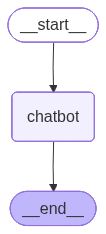

In [5]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### 실행

메시지는 `.from_messages()`처럼 `(역할, 텍스트)` 튜플로 사용할 수 있다.

| 튜플 | 변환 결과 |
|------|----------|
| `("human", "안녕")` | `HumanMessage(content="안녕")` |
| `("ai", "반가워")` | `AIMessage(content="반가워")` |
| `("system", "너는 봇")` | `SystemMessage(content="너는 봇")` |

결과의 각 메시지 객체는 `.type` 속성으로 종류를 확인할 수 있다. (`"human"`, `"ai"`, `"system"`)

In [6]:
result = graph.invoke({"messages": [("human", "LangGraph가 뭐야?")]})

for msg in result["messages"]:
    print(f"{msg.type}: {msg.content[:200]}")

# 사실, 
# llm.invoke([("human", "LangGraph가 뭐야?")])
# 한줄과 결과는 같다.

human: LangGraph가 뭐야?
ai: LangGraph는 자연어 처리(NLP)와 관련된 기술이나 도구를 지칭하는 용어일 수 있습니다. 그러나 "LangGraph"라는 이름의 특정한 프로젝트나 제품에 대한 정보는 제가 알고 있는 데이터에는 포함되어 있지 않습니다. 

일반적으로, "Lang"는 언어(Language)를 의미하고, "Graph"는 그래프(Graph) 구조를 의미할 수 있습니다. 따


## 그래프: 조건부 분기

Chain에서 불가능했던 **조건 분기**를 구현해보자.

시나리오: 사용자 입력의 언어를 감지해서 한국어면 한국어로, 영어면 영어로 답변하는 그래프.

```
START → detect_language → 한국어? → answer_ko → END
                          영어?  → answer_en → END
```

In [7]:
class RouterState(TypedDict):
    question: str
    language: str
    answer: str

In [8]:
def detect_language(state: RouterState):
    question = state["question"]
    result = llm.invoke(f"다음 문장의 언어가 한국어면 'ko', 영어면 'en'으로만 답해: {question}")
    return {"language": result.content.strip().lower()}


def answer_ko(state: RouterState):
    result = llm.invoke(f"한국어로 답변해줘: {state['question']}")
    return {"answer": result.content}


def answer_en(state: RouterState):
    result = llm.invoke(f"Answer in English: {state['question']}")
    return {"answer": result.content}

`add_edge`는 다음 노드가 고정되어 있지만, `add_conditional_edges`는 **함수의 반환값에 따라 다음 노드가 결정**된다.

```python
# 고정 연결
add_edge("A", "B")  # A 다음은 항상 B

# 조건부 연결
add_conditional_edges(
    "A",              # 출발 노드
    routing_function,  # State를 받아 문자열을 반환하는 함수
    {                  # 반환값 → 도착 노드 매핑
        "go_b": "B",
        "go_c": "C",
    },
)
```

In [9]:
def route_by_language(state: RouterState):
    """language에 따라 다음 노드를 결정하는 라우팅 함수"""
    if "ko" in state["language"]:
        return "answer_ko"
    else:
        return "answer_en"


graph_builder = StateGraph(RouterState)

graph_builder.add_node("detect_language", detect_language)
graph_builder.add_node("answer_ko", answer_ko)
graph_builder.add_node("answer_en", answer_en)

graph_builder.add_edge(START, "detect_language")
graph_builder.add_conditional_edges(
    "detect_language",    # 출발 노드
    route_by_language,    # 라우팅 함수
    {                     # 반환값 → 도착 노드 매핑
        "answer_ko": "answer_ko",
        "answer_en": "answer_en",
    },
)
graph_builder.add_edge("answer_ko", END)
graph_builder.add_edge("answer_en", END)

router_graph = graph_builder.compile()

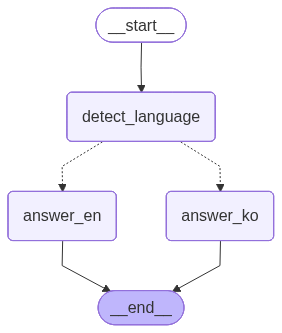

In [10]:
display(Image(router_graph.get_graph().draw_mermaid_png()))

In [11]:
# 한국어 입력
result = router_graph.invoke({"question": "파이썬의 장점이 뭐야?"})
print(f"언어: {result['language']}")
print(f"답변: {result['answer'][:200]}")
print()

# 영어 입력
result = router_graph.invoke({"question": "What are the benefits of Python?"})
print(f"언어: {result['language']}")
print(f"답변: {result['answer'][:200]}")

언어: ko
답변: 파이썬의 장점은 여러 가지가 있습니다:

1. **간결하고 읽기 쉬운 문법**: 파이썬은 코드가 간결하고 명확하여, 초보자도 쉽게 배울 수 있습니다. 가독성이 높아 유지보수도 용이합니다.

2. **다양한 라이브러리와 프레임워크**: 데이터 분석, 웹 개발, 인공지능 등 다양한 분야에서 사용할 수 있는 풍부한 라이브러리와 프레임워크가 있습니다. 예를 들어,

언어: en
답변: Python offers numerous benefits that make it a popular choice among developers and organizations. Here are some of the key advantages:

1. **Easy to Learn and Use**: Python has a simple and readable s


`stream`으로 실행하면 노드별 출력을 순서대로 받을 수 있다. 노드가 여러 개인 그래프에서 각 단계의 결과를 확인할 때 유용하다.

In [19]:
for event in router_graph.stream({"question": "파이썬의 장점이 뭐야?"}):
    for node_name, value in event.items():
        print(f"[{node_name}] {value}")
        print()

[detect_language] {'language': 'ko'}

[answer_ko] {'answer': '파이썬의 장점은 여러 가지가 있습니다:\n\n1. **간결하고 읽기 쉬운 문법**: 파이썬은 코드가 간결하고 명확하여, 초보자도 쉽게 배울 수 있습니다. 가독성이 높아 유지보수도 용이합니다.\n\n2. **다양한 라이브러리와 프레임워크**: 데이터 분석, 웹 개발, 인공지능 등 다양한 분야에서 사용할 수 있는 풍부한 라이브러리와 프레임워크가 있습니다. 예를 들어, NumPy, Pandas, TensorFlow, Django 등이 있습니다.\n\n3. **플랫폼 독립성**: 파이썬은 다양한 운영체제에서 실행될 수 있어, 윈도우, 리눅스, macOS 등에서 동일한 코드를 사용할 수 있습니다.\n\n4. **활발한 커뮤니티**: 파이썬은 전 세계적으로 많은 사용자와 개발자가 있어, 문제 해결이나 정보 공유가 활발하게 이루어집니다. 다양한 자료와 튜토리얼을 쉽게 찾을 수 있습니다.\n\n5. **다양한 용도**: 웹 개발, 데이터 과학, 머신러닝, 자동화 스크립트 등 다양한 분야에서 활용할 수 있어, 범용성이 높습니다.\n\n6. **객체 지향 프로그래밍 지원**: 파이썬은 객체 지향 프로그래밍을 지원하여, 코드의 재사용성과 구조화를 용이하게 합니다.\n\n이러한 장점들 덕분에 파이썬은 많은 개발자와 기업에서 선호되는 프로그래밍 언어입니다.'}



## 그래프: 루프

Chain에서 불가능했던 **반복**을 구현해보자.

시나리오: 숫자를 맞추는 게임. LLM이 1~100 사이의 숫자를 추측하고, 정답이 아니면 힌트를 받아 다시 시도한다.

```
START → guess → check → 정답? → END
                  ↑      오답? → guess로 돌아감
```

In [16]:
class GuessState(TypedDict):
    target: int
    guess: int
    low: int
    high: int
    attempts: int


def make_guess(state: GuessState):
    low = state.get("low", 1)
    high = state.get("high", 100)
    result = llm.invoke(f"{low}~{high} 사이의 숫자를 하나만 골라. 숫자만 답해.")
    guess = int("".join(filter(str.isdigit, result.content)))
    return {"guess": guess, "attempts": state.get("attempts", 0) + 1}


def check_answer(state: GuessState):
    target = state["target"]
    guess = state["guess"]
    if guess < target:
        return {"low": guess + 1}
    elif guess > target:
        return {"high": guess - 1}
    else:
        return {}


def is_correct(state: GuessState):
    if state["guess"] == state["target"]:
        print('성공!')
        return "end"
    if state["attempts"] >= 5:
        print("시도 횟수 초과")
        return "end"
    return "retry"


graph_builder = StateGraph(GuessState)

graph_builder.add_node("guess", make_guess)
graph_builder.add_node("check", check_answer)

graph_builder.add_edge(START, "guess")
graph_builder.add_edge("guess", "check")
graph_builder.add_conditional_edges(
    "check",
    is_correct,
    {
        "retry": "guess",  # 오답이면 다시 guess로
        "end": END,
    },
)

guess_graph = graph_builder.compile()

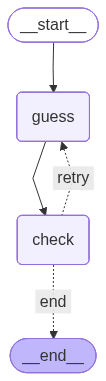

In [17]:
display(Image(guess_graph.get_graph().draw_mermaid_png()))

In [18]:
for event in guess_graph.stream({"target": 37}):
    for node_name, value in event.items():
        if node_name == "guess":
            print(f"--- 시도 {value['attempts']} ---")
        print(f"[{node_name}] {value}")
    print()

--- 시도 1 ---
[guess] {'guess': 57, 'attempts': 1}

[check] {'high': 56}

--- 시도 2 ---
[guess] {'guess': 27, 'attempts': 2}

[check] {'low': 28}

--- 시도 3 ---
[guess] {'guess': 42, 'attempts': 3}

[check] {'high': 41}

--- 시도 4 ---
[guess] {'guess': 35, 'attempts': 4}

[check] {'low': 36}

--- 시도 5 ---
[guess] {'guess': 38, 'attempts': 5}

시도 횟수 초과
[check] {'high': 37}



핵심 포인트:

- `add_conditional_edges`에서 `"retry": "guess"`로 **이전 노드로 돌아가는 엣지**를 만들 수 있다
- `attempts`로 무한 루프를 방지한다 — 실무에서도 반드시 탈출 조건이 필요하다
- State에 중간 결과(`hint`, `attempts`)가 자동으로 누적된다

## Reducer

State 필드에 reducer를 지정하면 업데이트 방식을 제어할 수 있다.

In [21]:
import operator

class ReducerDemo(TypedDict):
    name: str                                    # reducer 없음 → 덮어쓰기
    messages: Annotated[list, add_messages]       # add_messages → 메시지 추가 (같은 ID면 교체)
    logs: Annotated[list, operator.add]           # operator.add → 리스트 이어붙이기


def step_a(state: ReducerDemo):
    return {
        "name": "A가 설정",
        "messages": [HumanMessage(content="안녕", id="msg-1")],
        "logs": ["A 실행"],
    }


def step_b(state: ReducerDemo):
    return {
        "name": "B가 덮어씀",
        "messages": [AIMessage(content="반가워!", id="msg-2")],
        "logs": ["B 실행"],
    }


def step_c(state: ReducerDemo):
    return {
        "name": "C가 덮어씀",
        "messages": [HumanMessage(content="안녕 → 잘가로 교체됨", id="msg-1")],  # 같은 ID → 교체
        "logs": ["C 실행"],
    }


demo_builder = StateGraph(ReducerDemo)
demo_builder.add_node("a", step_a)
demo_builder.add_node("b", step_b)
demo_builder.add_node("c", step_c)
demo_builder.add_edge(START, "a")
demo_builder.add_edge("a", "b")
demo_builder.add_edge("b", "c")
demo_builder.add_edge("c", END)

demo_graph = demo_builder.compile()
result = demo_graph.invoke({"messages": [], "logs": []})

print(f"name: {result['name']}")
print(f"logs: {result['logs']}")
print(f"messages:")
for msg in result["messages"]:
    print(f"  {msg.type} (id={msg.id}): {msg.content}")

name: C가 덮어씀
logs: ['A 실행', 'B 실행', 'C 실행']
messages:
  human (id=msg-1): 안녕 → 잘가로 교체됨
  ai (id=msg-2): 반가워!


reducer 선택 가이드:

| 상황 | reducer | 동작 |
|------|---------|------|
| 최신 값만 필요 (이름, 상태 등) | 없음 | 덮어쓰기 |
| 대화 메시지 누적 | `add_messages` | 메시지 추가 + **같은 ID면 교체** |
| 로그, 결과 목록 누적 | `operator.add` | 단순 리스트 이어붙이기 (`+`) |

`add_messages`와 `operator.add`는 둘 다 리스트에 추가하지만, `add_messages`는 같은 ID의 메시지가 이미 있으면 교체한다. 메시지 수정/삭제가 필요할 때 이 동작이 중요하다.

State 스키마를 잘 설계하면 이후 모든 노드가 깔끔해진다. 이 부분은 앞으로 계속 반복된다.

## Chain vs LangGraph

| | Chain | LangGraph |
|---|---|---|
| 흐름 | 직선 (A → B → C) | 분기 + 루프 가능 |
| 상태 | 이전 단계 출력만 전달 | State로 전체 공유 |
| 제어 | 고정된 순서 | 조건에 따라 동적 결정 |
| 디버깅 | 각 단계 출력 확인 | 그래프 시각화 + 노드별 트레이싱 |
| 적합한 경우 | 단순 파이프라인 | 분기, 반복, 상태 관리가 필요한 경우 |

## 실습

### 실습 1: 감정 분석 라우터

사용자의 문장을 받아 감정을 분석하고, 긍정이면 긍정 응답, 부정이면 위로 응답을 생성하는 그래프를 만들어보자.

```
START → analyze → 긍정? → respond_positive → END
                   부정? → respond_negative → END
```

**요구사항**:
1. State: `text`(입력), `sentiment`(긍정/부정), `response`(응답)
2. `analyze` 노드: LLM에게 `"positive"` 또는 `"negative"`로만 답하게 해서 감정 분류
3. `respond_positive` / `respond_negative` 노드: 각각 긍정 응답, 위로 응답 생성
4. 라우팅 함수: `sentiment` 값에 따라 다음 노드 결정
5. `add_conditional_edges`로 분기 연결

**테스트 입력**:
```python
sentiment_graph.invoke({"text": "오늘 승진했어! 너무 기뻐!"})
sentiment_graph.invoke({"text": "프로젝트가 엎어졌어... 힘들다"})
```

In [25]:
# 실습 1 코드를 작성하세요

class State(TypedDict):
    text: str
    sentiment: str
    response: str

def analyze(state : State):
    """text를 입력받아 감정을 긍정 / 부정으로 분류한다."""
    text = state['text']
    response = llm.invoke(f"다음 문장에 대한 감정을 분석해줘. 긍정이면 'positive' 부정이면 'negative'로만 답변해. \n[문장]\n{text}")
    return {'sentiment' : response.content}

def response_positive(state: State):
    text = state['text']
    response = llm.invoke(f"다음 문장에 대해 공감하면서 긍정적으로 답변해줘. \n[문장]\n{text}")
    return {'response' : response.content}

def response_negative(state: State):
    text = state['text']
    response = llm.invoke(f"다음 문장에 대해 공감하면서 위로해줘. \n[문장]\n{text}")
    return {'response' : response.content}


def route_by_sentiment(state: State):
    sentiment = state['sentiment']
    if sentiment == 'positive':
        return 'positive'
    return 'negative'

builder = StateGraph(State)

builder.add_node("analyze", analyze )
builder.add_node("response_positive", response_positive)
builder.add_node("response_negative", response_negative)

builder.add_edge(START, "analyze")

builder.add_conditional_edges(
    "analyze",
    route_by_sentiment,
    {
        "positive": "response_positive",  
        "negative": "response_negative",
    },
)



builder.add_edge("response_positive", END)
builder.add_edge("response_negative", END)

sentiment_graph = builder.compile()

result = sentiment_graph.invoke({"text": "오늘 승진했어! 너무 기뻐!"})

print(result['sentiment'])
print(result['response'])
print()

result = sentiment_graph.invoke({"text": "프로젝트가 엎어졌어... 힘들다"})

print(result['sentiment'])
print(result['response'])

positive
와, 정말 축하해! 승진 소식 듣고 나니 나까지 기분이 좋아져! 그동안의 노력이 결실을 맺은 것 같아 정말 대단해. 앞으로도 더 많은 성과가 있기를 바랄게!

negative
정말 힘든 상황이네요. 열심히 준비한 프로젝트가 엎어지면 마음이 많이 아프고 실망스러울 거예요. 그동안의 노력이 헛된 것처럼 느껴질 수도 있지만, 이런 경험도 나중에 큰 자산이 될 수 있어요. 지금은 힘들겠지만, 조금씩 마음을 추스르고 다시 일어설 수 있기를 바랄게요. 당신의 노력을 응원합니다.


### 실습 2: 글 작성 → 검토 → 재작성

주제를 받아 짧은 글을 작성하고, 검토 후 품질이 부족하면 피드백을 반영해 다시 작성하는 그래프를 만들어보자.

```
START → write → review → 통과? → END
                  ↑       미흡? → write로 돌아감
```

**요구사항**:
1. State: `topic`(주제), `draft`(작성된 글), `feedback`(피드백), `passed`(통과 여부), `attempts`(시도 횟수)
2. `write` 노드: topic으로 2~3문장 글 작성. feedback이 있으면 프롬프트에 포함해서 반영
3. `review` 노드: LLM에게 `"PASS"` 또는 `"FAIL: 개선할 점"` 형식으로 답하게 해서 passed(bool)와 feedback 결정
4. 라우팅 함수: passed가 True이거나 attempts가 3 이상이면 END, 아니면 write로
5. `stream`으로 실행해서 시도별 과정 확인

**테스트 입력**:
```python
writing_graph.stream({"topic": "AI가 교육에 미치는 영향"})
```

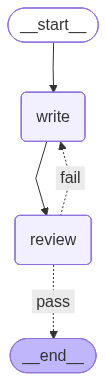

[write] {'draft': 'AI는 개인 맞춤형 학습 경험을 제공함으로써 학생들의 이해도를 높이고 교육의 효율성을 극대화하는 데 기여하고 있다.', 'attempts': 1}

[review] {'passed': False, 'freedback': ' 글이 너무 짧아 품질이 충분하지 못함.'}

[write] {'draft': 'AI는 개인 맞춤형 학습 경험을 제공하고, 학생들의 학습 성향을 분석하여 효과적인 교육 방법을 제시함으로써 교육의 질을 획기적으로 향상시키고 있다.', 'attempts': 2}

[review] {'passed': True}



In [ ]:
# 실습 2 코드를 작성하세요

class State(TypedDict):
    topic: str
    draft: str
    freedback: str
    passed: bool

    attempts: int

def write(state: State):
    topic = state['topic']
    freedback = state.get('freedback', "")

    if freedback:
        response = llm.invoke(f"다음 주제에 맞춰 피드백을 반영하여 2~3문장의 글을 작성해줘. \n[주제] : \n{topic} \n[피드백] : \n{freedback}")
    else:
        response = llm.invoke(f"다음 주제에 맞춰서 1문장의 글을 작성해줘. \n[주제] : \n{topic}")
    draft = response.content

    return {'draft' : draft, "attempts" : state.get('attempts', 0) + 1}

def review(state: State):
    draft = state['draft']

    # 규칙보다는 structured output을 통해 정확한 응답을 바라는 것이 좋습니다.
    response = llm.invoke(f"""다음 글을 규칙에 맞게 리뷰해줘. 
                          [규칙] 
                            - 품질이 충분하면 "PASS"로 응답해줘. 엄격하게 판단해줘.
                            - 품질이 충분하지 못하면 "FAIL : 부족한 이유"로 응답해줘.
                            - 너무 글이 짧으면 품질이 충분하지 못한 상황이야.
                          [글] 
                          f{draft}""")
    content = response.content

    if 'PASS' in content.upper():
        return {'passed' : True}
    else:
        freedback = content.replace('FAIL :', "")
        return {'passed' : False, "freedback" : freedback}

def route_by_passed(state: State):
    passed = state["passed"]
    attempt = state['attempts']
    if passed:
        return 'pass'
    
    if attempt > 5:
        return 'pass'
    return 'fail'


builder = StateGraph(State)

builder.add_node("write",  write)
builder.add_node("review",  review)

builder.add_edge(START, "write")
builder.add_edge("write", "review")


builder.add_conditional_edges(
    "review",
    route_by_passed,
    {
        "fail": "write",  
        "pass": END,
    },
)

builder.add_edge("review", END)

graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))

# result = graph.invoke({'topic' : "AI가 교육에 미치는 영향"})

for event in graph.stream({'topic' : "AI가 교육에 미치는 영향"}):
    for node_name, value in event.items():
        print(f"[{node_name}] {value}")
        print()